In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
%cd drive/My\ Drive/mSHIFT_SHeS/FoodDB\ matches/NDNS_analysis/Matching\ paper

/content/drive/My Drive/mSHIFT_SHeS/FoodDB matches/NDNS_analysis/Matching paper


In [ ]:
!pip install pyreadstat
import pyreadstat

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 9.1 MB/s eta 0:00:00


In [4]:
import pandas as pd
import numpy as np
from pathlib import Path
import sys
import json
import dill
import time

In [5]:
df_baseline = pd.read_parquet("data/df_baseline.parquet")

In [8]:
np.average(df_baseline['median_GHG'], weights = df_baseline['Sample Weight'])

np.float64(4.469722429860605)

In [9]:
diet_data = pd.read_parquet("data/diet_data.parquet")

In [10]:
diet_data['median_GHG']

,median_GHG
0,0.117707
1,0.028493
2,0.031647
3,0.031647
4,0.028493
...,...
117201,0.136432
117202,0.000000
117203,0.000183
117204,0.053467


In [11]:
diet_data.to_csv("data/diet_data.csv")
df_baseline.to_csv("data/df_baseline.csv")

In [ ]:
%ls

data/  notebooks/  results/


In [ ]:
# Add the parent directory of the notebook to sys.path, enables module imports from analysis_code
sys.path.append(str(Path().resolve() / 'notebooks/analysis_code'))

In [ ]:
%load_ext rpy2.ipython

In [ ]:
%%R
install.packages("survey")
install.packages("readxl")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
also installing the dependencies ‘minqa’, ‘numDeriv’, ‘mitools’, ‘RcppArmadillo’

trying URL 'https://cran.rstudio.com/src/contrib/minqa_1.2.8.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/numDeriv_2016.8-1.1.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/mitools_2.4.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/RcppArmadillo_15.2.7-1.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/survey_4.5.tar.gz'

The downloaded source packages are in
	‘/tmp/RtmpldmX1f/downloaded_packages’
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cran.rstudio.com/src/contrib/readxl_1.5.0.tar.gz'
Content type 'application/x-gzip' length 2088990 bytes (2.0 MB)
downloaded 2.0 MB


The downloaded source packages are in
	‘/tmp/RtmpldmX1f/downloaded_packages’


In [ ]:
from rpy2.robjects.vectors import StrVector, FloatVector, IntVector
from rpy2.robjects import DataFrame
from rpy2.robjects import r, pandas2ri
from rpy2.robjects.packages import importr

In [ ]:
survey = importr("survey")
readxl = importr("readxl")
dplyr = importr("dplyr")

In [ ]:
version = rpy2.robjects['packageVersion']('survey')
print(version)

In [ ]:
!python --version

Python 3.11.13


In [ ]:
from data_processing import add_env_data_ndns, print_columns, add_variable, nutrient_intake, search_substrings, add_non_diet_variables, filter_dataframes, results_table_demographic_group

In [ ]:
data_path = Path("data")
results_path = Path("results")

In [ ]:
ndb_df = pd.read_csv(data_path / 'NDB_matching_data_FINAL.csv')

In [ ]:
ind_data, _ = pyreadstat.read_dta(data_path / "ndns_rp_yr9-11a_indiv_20211020.dta")
ndns_df_9 = pd.read_stata(data_path / 'ndns_rp_yr9a_foodleveldietarydata_uk_20210831.dta')
ndns_df_10 = pd.read_stata(data_path / 'ndns_rp_yr10a_foodleveldietarydata_uk_20210831.dta')
ndns_df_11 = pd.read_stata(data_path / 'ndns_rp_yr11a_foodleveldietarydata_uk_20210831.dta')

In [ ]:
diet_data = pd.concat([ndns_df_9, ndns_df_10, ndns_df_11], axis=0)

In [ ]:
df_impacts = pd.read_parquet("data/df_impacts_per_100g_1902.parquet")

In [ ]:
df_impacts['median_GHG']

In [ ]:
# Load the mapping from missing NDNS items to closely matched NDB items
ndns_ndb_mapping = pd.read_csv(data_path / "NDNS.fNDB na matches.csv")

In [ ]:
ndns_ndb_mapping['matched'].isin(df_impacts.index.tolist()).sum()

np.int64(2450)

In [ ]:
len(df_impacts) - df_impacts['median_GHG'].isnull().sum()

np.int64(2908)

In [ ]:
# Run sensitivity analysis on values in drink_conversion_dict
with open('data/drink_conversion_dict_MW.json', 'r') as f:
  drink_conversion_dict = json.load(f)

In [ ]:
mean_env_columns = np.loadtxt(data_path / "indicator_lists/mean_env_columns.txt", dtype = str).tolist()
error_columns = np.loadtxt(data_path / "indicator_lists/error_columns.txt", dtype = str).tolist()
env_columns = np.loadtxt(data_path / "indicator_lists/env_columns.txt", dtype = str).tolist()
nutrients = np.loadtxt(data_path / "indicator_lists/nutrients.txt", dtype = str).tolist()
all_food_groups = np.loadtxt(data_path / "indicator_lists/all_food_groups.txt", dtype = str).tolist()
all_indicators = env_columns + nutrients + all_food_groups

In [ ]:
diet_data.loc[:, env_columns] = np.nan


In [ ]:
diet_data = diet_data.apply(lambda row: add_env_data_ndns(row,
                                                          NDB_data = ndb_df,
                                                          ndns_ndb_mapping = ndns_ndb_mapping,
                                                          df_impacts=df_impacts,
                                                          mean_env_columns=mean_env_columns,
                                                          error_columns=error_columns,
                                                          conversion_dict = drink_conversion_dict
                                                               ),
                            axis=1)

In [ ]:
# Some column names are incorrectly read in due to the \mu character
columns_to_rename={'variabl04':'VitaminA', 'variabl05':'VitaminD', 'variabl06':'VitaminB12', 'variabl09':'Iodine', 'variabl000':'Selenium',
                                      'variabl0':'Retinol', 'variabl00':'TotCarotene', 'variabl01':'Alpcarotene', 'variabl02':'Betacarotene', 'variabl03':'BCryptoxanthin',
                                      'variabl07':'Folate', 'variabl08': 'Biotin'}

diet_data.rename(columns=columns_to_rename, inplace=True)

In [ ]:
diet_data.to_parquet(data_path / "diet_data.parquet")

In [ ]:
print_columns(diet_data)

In [ ]:
diet_data_ids = diet_data['seriali'].unique().tolist()
df_baseline = pd.DataFrame(index=diet_data_ids, columns=all_indicators)

In [ ]:
df_baseline = df_baseline.apply(lambda row: nutrient_intake(row,
                                                            diet_data=diet_data,
                                                            nutrients=all_indicators,
                                                            error_columns=error_columns),
                                axis=1)


## distribution of impacts

In [ ]:
ind_data

In [ ]:
df_impacts['median_GHG'].median()

0.2120727910655295

In [ ]:
df_impacts['median_GHG'].mean()

np.float64(0.5090440589520558)

In [ ]:
def add_sw(row:pd.Series, ind_data:pd.DataFrame):

  id = row['seriali']
  SW = ind_data[ind_data['seriali']==id]['wti_Y911'].iloc[0]

  return SW

In [ ]:
diet_data['Sample Weight'] = diet_data.apply(lambda row: add_sw(row=row, ind_data=ind_data), axis=1)

In [ ]:
diet_data.to_parquet(data_path / "diet_data.parquet")

In [ ]:

plt.rcParams["font.family"] = 'serif'
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams["axes.formatter.use_mathtext"] = True

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


median_GHG 4.266608785057408


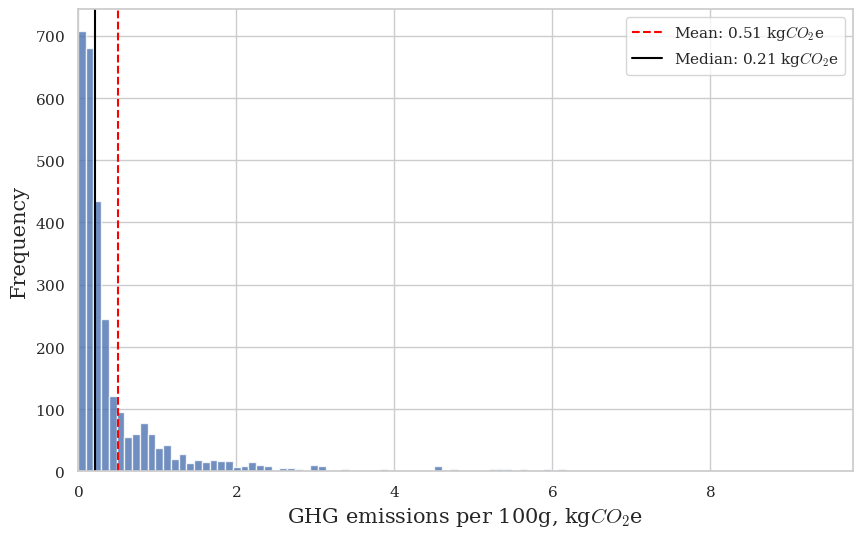

median_Land 6.339178851869339


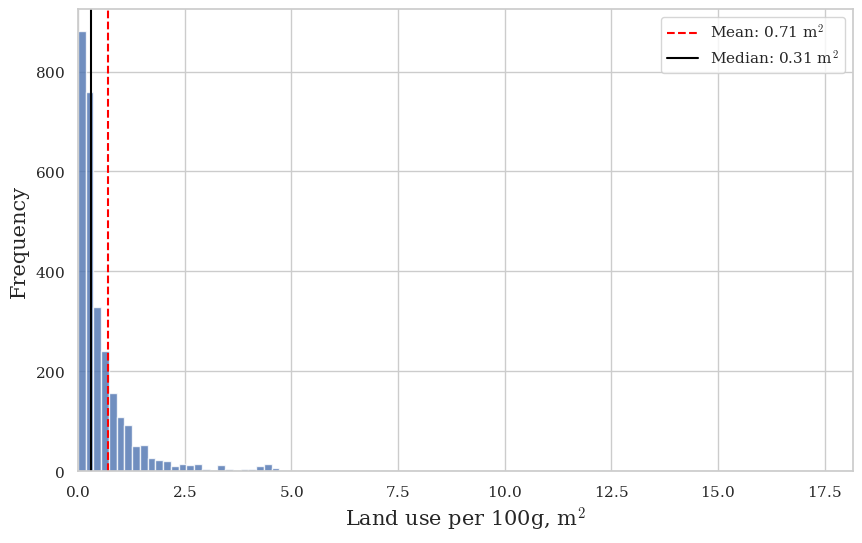

median_Eut 5.348715511786325


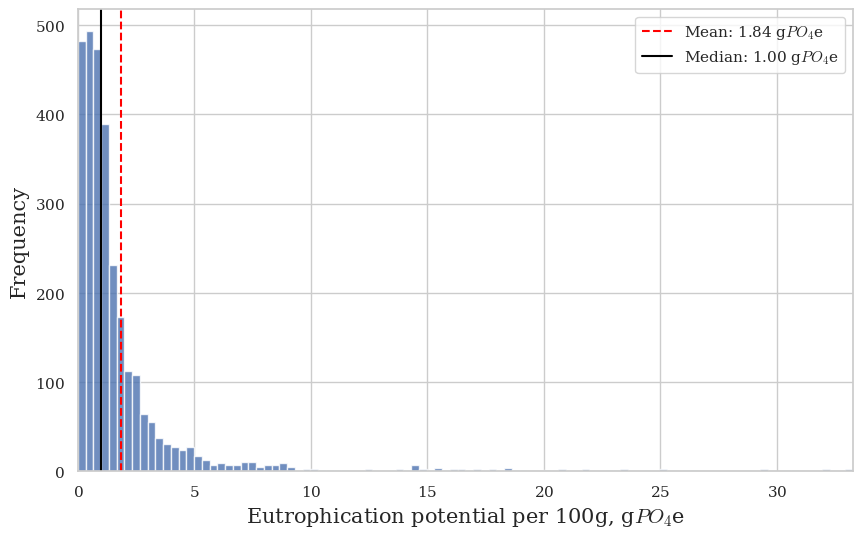

median_WaterUse 3.6169030016914667


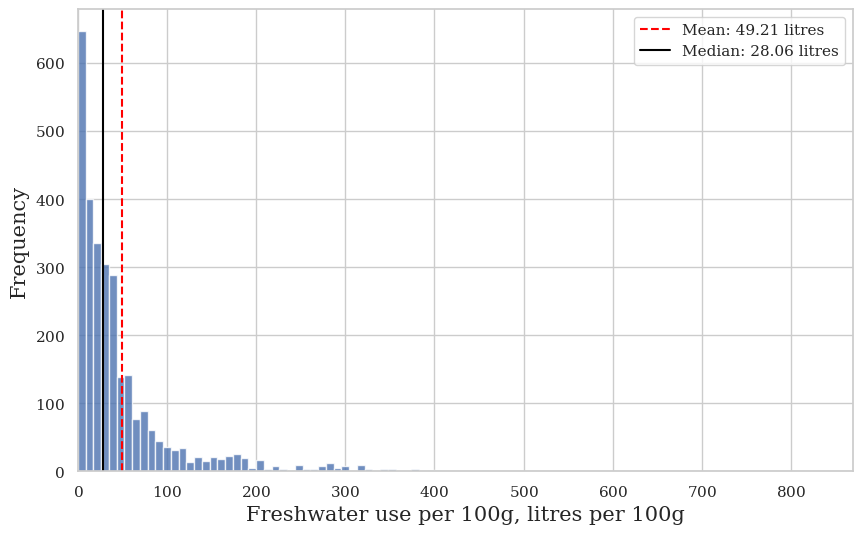

median_price_sim 1.7043166111757806


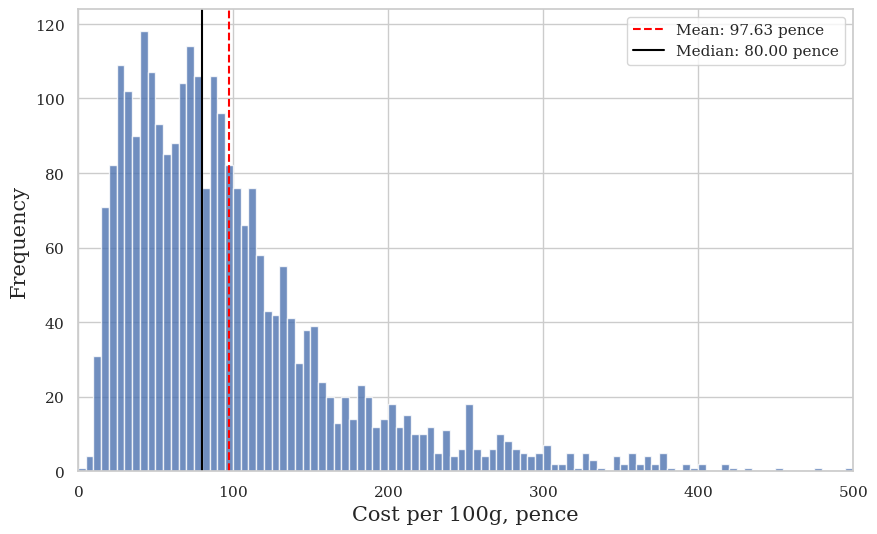

In [ ]:
indicator = 'median_GHG'


indicator_label_dict = {'median_GHG': "GHG emissions per 100g, kg$CO_2$e",
                        'median_Land': "Land use per 100g, m$^2$",
                        'median_Eut': "Eutrophication potential per 100g, g$PO_4$e",
                        'median_WaterUse': "Freshwater use per 100g, litres per 100g",
                        'median_price_sim': "Cost per 100g, pence"
                        }

indicator_unit_dict = {"median_GHG": "kg$CO_2$e",
                       "median_Land":  "m$^2$",
                       "median_Eut": "g$PO_4$e",
                       "median_WaterUse": "litres",
                       "median_price_sim": "pence"
                       }


for indicator in indicator_label_dict.keys():
  # Calculate statistics
  mean_val = df_impacts[indicator].mean()
  median_val = df_impacts[indicator].median()
  skew_val = df_impacts[indicator].skew()

  print(indicator, skew_val)

  # Create the plot
  plt.figure(figsize=(10, 6))
  plt.hist(df_impacts[indicator].dropna(), bins=100, alpha=0.8)

  # Add vertical lines
  plt.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f} {indicator_unit_dict[indicator]}')
  plt.axvline(median_val, color='black', linestyle='-', label=f'Median: {median_val:.2f} {indicator_unit_dict[indicator]}')

  # # Add skewness text
  # plt.text(0.95, 0.95, f'Skewness: {skew_val:.2f}',
  #          transform=plt.gca().transAxes, verticalalignment='top', horizontalalignment='right',
  #          bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

  plt.xlabel(indicator_label_dict[indicator], fontsize=15)
  plt.ylabel('Frequency', fontsize=15)
  plt.xlim(0, df_impacts[indicator].max())
  plt.legend()

  plt.savefig(results_path / f"{indicator}_dist.png", dpi=300)


  plt.show()



In [ ]:
indicator = 'median_Eut'

skewness = df_impacts[indicator].skew()
mean_val = df_impacts[indicator].mean()
median_val = df_impacts[indicator].median()

print(f"Skewness Coefficient: {skewness:.4f}")
print(f"Mean: {mean_val:.4f}")
print(f"Median: {median_val:.4f}")

if skewness < 0:
    print("Confirming: The distribution is left-skewed (negative skew).")
elif skewness > 0:
    print("Actually, the distribution is right-skewed (positive skew).")
else:
    print("The distribution is symmetrical.")

Skewness Coefficient: 5.3487
Mean: 1.8438
Median: 1.0002
Actually, the distribution is right-skewed (positive skew).


In [ ]:
# Sort impacts in descending order
sorted_impacts = df_impacts['median_GHG'].sort_values(ascending=False).dropna()
total_sum_impacts = sorted_impacts.sum()

# Calculate cumulative sum and percentage
cumulative_impacts = sorted_impacts.cumsum()
cumulative_percentage = (cumulative_impacts / total_sum_impacts) * 100

# Find number of items for specific thresholds
items_for_50pct = (cumulative_percentage <= 50).sum() + 1
items_for_80pct = (cumulative_percentage <= 80).sum() + 1
total_items = len(sorted_impacts)

print(f"Total items with impact data: {total_items}")
print(f"{items_for_50pct} items ({items_for_50pct/total_items*100:.2f}%) contribute to 50% of the total impact sum.")
print(f"{items_for_80pct} items ({items_for_80pct/total_items*100:.2f}%) contribute to 80% of the total impact sum.")

Total items with impact data: 2908
278 items (9.56%) contribute to 50% of the total impact sum.
940 items (32.32%) contribute to 80% of the total impact sum.


In [ ]:
len(df_impacts[df_impacts['median_GHG']>2])/len(df_impacts)

0.050119331742243436

In [ ]:
df_impacts[df_impacts['median_GHG']>2]

,tot_num_products,num_prods_fooddb_2022,num_prods_fooddb_2021,num_prods_fooddb_2019,num_prods_open_food_facts,num_prods_recipeDB,sd_mean_GHG,sd_mean_Land,sd_mean_WatScar,sd_mean_Eut,...,sd_price_2019,sd_median_size_2019,sd_median_price_2019,mean_price_2019,mean_size_2019,median_price_2019,median_size_2019,mean_price_sim,median_price_sim,sd_price_sim
ndb_cat,,,,,,,,,,,,,,,,,,,,,
Alcoholic soft drink (e.g. Crabbies ginger beer),1.0,0.0,0.0,0.0,1.0,0.0,1.337804,0.182081,20645.082400,19.411830,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,60.606061,60.606061,0.0
"Animal fat (e.g. beef dripping, chicken fat)",2.0,1.0,0.0,1.0,0.0,0.0,0.889473,7.340006,3033.691942,64.321104,...,0.0,0.000000,1.131371,27.200000,250.0,27.200000,250.0,69.666667,69.666667,0.0
"Bacon cheeseburger, in a bun (homemade)",6.0,1.0,1.0,0.0,0.0,4.0,1.303275,6.606034,1162.295095,9.107190,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,130.890052,130.890052,0.0
Beef & vegetable hot pot/hotpot,1.0,1.0,0.0,0.0,0.0,0.0,1.243795,10.420850,4242.160696,90.993370,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,110.000000,110.000000,0.0
"Beef Sausage, grilled",2.0,2.0,0.0,0.0,0.0,0.0,2.991020,15.233217,2553.420053,36.504204,...,0.0,NaN,NaN,87.941176,340.0,87.941176,340.0,88.235294,88.235294,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Veal escalope/schnitzel,1.0,1.0,0.0,0.0,0.0,0.0,7.017252,34.862720,4654.569137,6.659526,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,299.512543,299.512543,0.0
Veal in a white/cream sauce,10.0,3.0,0.0,0.0,0.0,7.0,1.969223,9.780637,1413.370537,1.950008,...,0.0,NaN,NaN,311.111111,180.0,311.111111,180.0,263.432915,263.432915,0.0
"Veal mince, stewed",3.0,3.0,0.0,0.0,0.0,0.0,5.072960,25.200532,3259.598855,4.815288,...,0.0,NaN,NaN,143.000000,300.0,143.000000,300.0,135.366667,135.366667,0.0


In [ ]:
df_impacts['median_GHG'].quantile(0.95)

np.float64(2.028070707132528)

In [ ]:
threshold = df_impacts['median_GHG'].quantile(0.95)
high_ghg_items = ndb_df[ndb_df['Local description'].isin(df_impacts[df_impacts['median_GHG'] > threshold].index.tolist())]
group_counts = high_ghg_items['NDNS Food group'].value_counts()
group_percentages = (group_counts / len(high_ghg_items)) * 100
food_group_summary = pd.DataFrame({
    'Count': group_counts,
    'Percentage (%)': group_percentages
})

print(f"Total items with median_GHG > 2: {len(high_ghg_items)}")
display(food_group_summary)

Total items with median_GHG > 2: 147


,Count,Percentage (%)
NDNS Food group,,
OTHER BEEF & VEAL INCLUDING HOMEMADE RECIPE DISHES,58,39.455782
OTHER LAMB INCLUDING HOMEMADE RECIPE DISHES,15,10.204082
BURGERS AND KEBABS PURCHASED,14,9.523810
OTHER WHITE FISH INCLUDING HOMEMADE DISHES,10,6.802721
LIVER AND DISHES,7,4.761905
OTHER SHELLFISH INCLUDING HOMEMADE DISHES,7,4.761905
OTHER MEAT INCLUDING HOMEMADE RECIPE DISHES,6,4.081633
MANUFACTURED BEEF PRODUCTS INCLUDING READY MEALS,5,3.401361
OTHER MEAT PRODUCTS MANUFACTURED INCL READY MEALS,4,2.721088


In [ ]:
threshold = df_impacts['median_price_sim'].quantile(0.95)
high_ghg_items = ndb_df[ndb_df['Local description'].isin(df_impacts[df_impacts['median_price_sim'] > threshold].index.tolist())]
group_counts = high_ghg_items['NDNS Food group'].value_counts()
group_percentages = (group_counts / len(high_ghg_items)) * 100

food_group_summary = pd.DataFrame({
    'Count': group_counts,
    'Percentage (%)': group_percentages
})

print(f"Total items with median_price > {threshold}: {len(high_ghg_items)}")
display(food_group_summary)

Total items with median_price > 250.0: 131


,Count,Percentage (%)
NDNS Food group,,
SAVOURY SAUCES PICKLES GRAVIES & CONDIMENTS,19,14.503817
OTHER BEEF & VEAL INCLUDING HOMEMADE RECIPE DISHES,11,8.396947
CHOCOLATE CONFECTIONERY,8,6.106870
BISCUITS MANUFACTURED / RETAIL,7,5.343511
OTHER WHITE FISH INCLUDING HOMEMADE DISHES,6,4.580153
OTHER SHELLFISH INCLUDING HOMEMADE DISHES,6,4.580153
OTHER CHEESE,5,3.816794
SANDWICHES,5,3.816794
SUGAR CONFECTIONERY,5,3.816794


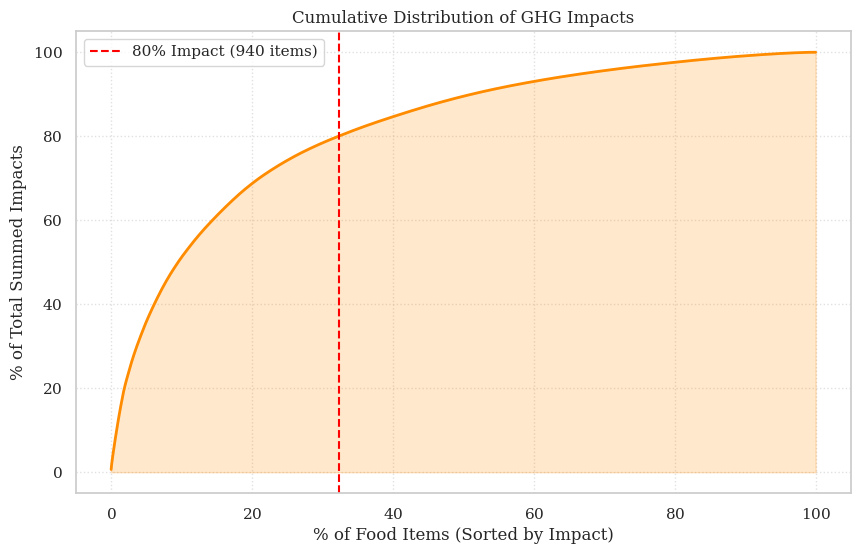

In [ ]:
# Visualize the Lorenz-style curve for impact concentration
plt.figure(figsize=(10, 6))
plt.plot(np.arange(len(cumulative_percentage)) / len(cumulative_percentage) * 100, cumulative_percentage, color='darkorange', lw=2)
plt.fill_between(np.arange(len(cumulative_percentage)) / len(cumulative_percentage) * 100, cumulative_percentage, alpha=0.2, color='darkorange')
plt.title('Cumulative Distribution of GHG Impacts')
plt.xlabel('% of Food Items (Sorted by Impact)')
plt.ylabel('% of Total Summed Impacts')
plt.axvline(x=(items_for_80pct/total_items*100), color='red', linestyle='--', label=f'80% Impact ({items_for_80pct} items)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [ ]:
# Calculate the 95th percentile threshold
threshold = df_impacts['median_GHG'].quantile(0.99)

# Identify items in the top 5% (above 95th percentile)
high_impact_items = df_impacts[df_impacts['median_GHG'] >= threshold].sort_values(by='median_GHG', ascending=False)

print(f"95th Percentile Threshold: {threshold:.4f}")
print(f"Number of items in top 5%: {len(high_impact_items)}")

# Display top 10 highest impact items
display(high_impact_items.head(10))

95th Percentile Threshold: 5.0946
Number of items in top 5%: 30


,tot_num_products,num_prods_fooddb_2022,num_prods_fooddb_2021,num_prods_fooddb_2019,num_prods_open_food_facts,num_prods_recipeDB,sd_mean_GHG,sd_mean_Land,sd_mean_WatScar,sd_mean_Eut,...,sd_price_2019,sd_median_size_2019,sd_median_price_2019,mean_price_2019,mean_size_2019,median_price_2019,median_size_2019,mean_price_sim,median_price_sim,sd_price_sim
ndb_cat,,,,,,,,,,,,,,,,,,,,,
"Stewing steak and kidney, uncooked",1.0,1.0,0.0,0.0,0.0,0.0,6.710239,33.345080,4299.676202,7.434916,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,80.000000,80.000000,0.0
"Steak and kidney, stewed (no gravy)",1.0,1.0,0.0,0.0,0.0,0.0,6.710239,33.345080,4299.676202,7.434916,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,80.000000,80.000000,0.0
"Beef fillet steak, fried",9.0,3.0,0.0,6.0,0.0,0.0,3.424191,17.057686,2180.905490,3.176187,...,0.0,51.146847,78.230848,369.914248,208.000000,369.914248,208.000000,376.149783,376.149783,0.0
"Beef fillet steak, grilled",9.0,3.0,0.0,6.0,0.0,0.0,3.424191,17.057686,2180.905490,3.176187,...,0.0,51.146847,78.230848,369.914248,208.000000,369.914248,208.000000,376.149783,376.149783,0.0
"Beef sirloin steak, grilled",5.0,3.0,1.0,1.0,0.0,0.0,3.601158,18.192406,2556.270566,25.945518,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,274.849220,274.849220,0.0
"Beef sirloin steak, fried",5.0,3.0,1.0,1.0,0.0,0.0,3.601158,18.192406,2556.270566,25.945518,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,274.286157,274.286157,0.0
"Beef rump steak, uncooked (including fat)",12.0,6.0,3.0,3.0,0.0,0.0,2.714113,13.612738,1792.501341,11.020940,...,0.0,113.907857,43.874388,141.143791,282.500000,141.143791,282.500000,173.130266,173.130266,0.0
"Stewing steak/beef steak/braising steak, uncooked",2.0,1.0,0.0,1.0,0.0,0.0,7.356256,37.065135,4645.152434,6.789666,...,0.0,NaN,NaN,83.250000,400.000000,83.250000,400.000000,105.000000,105.000000,0.0
"Beef rump steak, grilled",8.0,4.0,2.0,2.0,0.0,0.0,3.403025,17.058504,2222.179951,11.817008,...,0.0,27.537853,47.813544,151.154684,226.666667,151.154684,226.666667,170.572532,170.572532,0.0


In [ ]:
ndb_df.head()

,Unnamed: 0,Local description,Food composition record ID,NDNS Food group
0,0,7 Up free / light,8445,SOFT DRINKS LOW CALORIE CARBONATED
1,1,"Apple and blackcurrant squash / juice, with AD...",11581,SOFT DRINKS NOT LOW CALORIE CONCENTRATED
2,2,"Ackee, canned",1651,CANNED FRUIT IN JUICE
3,3,Aduki beans,8826,BEANS AND PULSES INCL READY MEAL & HOMEMADE DI...
4,4,"Adcal D3, calcium (600mg) with vitamin D (10ug...",10097,CALCIUM ONLY OR WITH VITAMIN D


In [ ]:
ndb_df[ndb_df['Local description'].isin(high_impact_items.index)]

,Unnamed: 0,Local description,Food composition record ID,NDNS Food group
6,6,"Animal fat (e.g. beef dripping, chicken fat)",858,OTHER COOKING FATS AND OILS NOT PUFA
70,70,"Beef joint, uncooked (including fat)",949,OTHER BEEF & VEAL INCLUDING HOMEMADE RECIPE DI...
74,74,"Beef meatballs, grilled or oven baked",8264,BURGERS AND KEBABS PURCHASED
80,80,"Beef rump steak, uncooked (including fat)",949,OTHER BEEF & VEAL INCLUDING HOMEMADE RECIPE DI...
86,86,"Beef sirloin steak, uncooked (including fat)",949,OTHER BEEF & VEAL INCLUDING HOMEMADE RECIPE DI...
632,632,"Minced beef, fried",3829,OTHER BEEF & VEAL INCLUDING HOMEMADE RECIPE DI...
699,699,"Ox liver, uncooked",1226,LIVER AND DISHES
835,835,"Roast beef slices, pre-packed/deli",5309,OTHER BEEF & VEAL INCLUDING HOMEMADE RECIPE DI...
933,933,"Steak and kidney, stewed (no gravy)",3460,OTHER BEEF & VEAL INCLUDING HOMEMADE RECIPE DI...
946,946,"Stewing steak/beef steak/braising steak, uncooked",9482,OTHER BEEF & VEAL INCLUDING HOMEMADE RECIPE DI...


In [ ]:
diet_data = pd.read_parquet(data_path / "diet_data.parquet")

In [ ]:
diet_data[['median_GHG', 'FoodName', 'FoodNumber']]

,median_GHG,FoodName,FoodNumber
0,0.117707,MILK SEMI-SKIMMED PASTEURISED WINTER,8543
1,0.028493,TEA WEAK INFUSION,2315
2,0.031647,SUGAR WHITE,2205
3,0.031647,SUGAR WHITE,2205
4,0.028493,TEA WEAK INFUSION,2315
...,...,...,...
117201,0.136432,LENTILS SPLIT BOILED,1758
117202,0.000000,WATER NOT AS A DILUENT,5000
117203,0.000183,VEGETABLE OIL POLYUNSATURATED EG SUNFLOWER,873
117204,0.053467,JAM WITH EDIBLE SEEDS PURCHASED,2215


In [ ]:
# 1. Map high impact items (from df_impacts index) to NDNS FoodNumbers
# ndns_ndb_mapping maps 'FoodNumber' to 'matched' (which corresponds to df_impacts index)
high_impact_names = high_impact_items.index.tolist()
high_impact_mapping = ndns_ndb_mapping[ndns_ndb_mapping['matched'].isin(high_impact_names)]
high_impact_food_numbers = high_impact_mapping['FoodNumber'].unique().tolist()

# 2. Calculate total emissions in diet_data
# Emissions per row is likely median_GHG * (amount consumed / 100), but assuming 'median_GHG'
# in diet_data is already weighted by the amount consumed if it's derived from nutrient_intake.
# If it's the impact per 100g, we need to multiply by (TotalGrams / 100).

# Let's check if 'TotalGrams' exists and calculate total emissions
if 'TotalGrams' in diet_data.columns:
    diet_data['row_emissions'] = diet_data['median_GHG'] * (diet_data['TotalGrams'] / 100)
else:
    # Fallback if median_GHG is already the absolute amount for that row
    diet_data['row_emissions'] = diet_data['median_GHG']

total_dietary_emissions = diet_data['row_emissions'].sum()

# 3. Calculate emissions from high impact items
high_impact_diet_data = diet_data[diet_data['FoodNumber'].isin(high_impact_food_numbers)]
high_impact_emissions = high_impact_diet_data['row_emissions'].sum()

# 4. Result
proportion = (high_impact_emissions / total_dietary_emissions) * 100

print(f"Total items in high impact list: {len(high_impact_names)}")
print(f"Corresponding NDNS Food Codes found: {len(high_impact_food_numbers)}")
print(f"Total Dietary Emissions: {total_dietary_emissions:.2f}")
print(f"Emissions from Top X% Items: {high_impact_emissions:.2f}")
print(f"Proportion of total emissions: {proportion:.2f}%")

Total items in high impact list: 30
Corresponding NDNS Food Codes found: 17
Total Dietary Emissions: 81532.83
Emissions from Top X% Items: 1595.78
Proportion of total emissions: 1.96%


In [ ]:
ndns_ndb_mapping

,FoodNumber,NDNSFoodName,matched,matched_code,AV CHEX
0,3,BARLEY PEARL WHITE BOILED IN WATER,Barley (e.g pearl barley/wholegrain),5,NaN
1,10,CORN MEAL UNSIFTED DRIED,Cornmeal,9,NaN
2,9371,"PASTA, EGG, FRESH, PLAIN BOILED",Egg noodles,32,NaN
3,27,PASTA MACARONI BOILED,"Pasta white/tricolore, any shape (e.g. penne, ...",34,NaN
4,9172,VEGETABLE RAVIOLI CANNED IN TOMATO SAUCE,"Ravioli (filled pasta) in tomato sauce, canned",39,NaN
...,...,...,...,...,...
2792,10840,VITABIOTICS WELLWOMAN DRINK,???,???,Check
2793,11072,"VITAMIN K, ANY STRENGTH, ANY BRAND",???,???,Check
2794,10715,WATER RETENTION TABLETS WITH DANDELION EXTRACT,???,???,Check
2795,10431,WILD YAM CAPSULES,???,???,Check


### Drink conversion factor sensitivity analysis

---



In [ ]:
diet_data = pd.read_parquet(data_path / "diet_data.parquet")
diet_data_SA = diet_data.copy()

In [ ]:

0.01 += conversion*0.01

0.002

In [ ]:
conversion_factors_MW = {
    # 10g leaves per litre water, strained after 5 minutes; 10 samples
    "TEA WEAK INFUSION": 0.01,
    # Assuming the same ratio as TEA WEAK INFUSION
    'HERBAL TEA AS SERVED': 0.01,
        # Ground and filter coffee; 34g per litre water boiled in percolator and strained
       'COFFEE FRESH WEAK INFUSION': 0.039,
    'TEA HERB AND FRUIT MIX AS SERVED NO MILK': 0.01,
       'TEA, GREEN, INFUSION': 0.01,
       'TEA NOT STRONG INFUSION DECAFFEINATED' :0.01,
      # Ground and filter coffee; 69g per litre water boiled in percolator and strained
       'COFFEE FRESH STRONG INFUSION':0.069,
     'TEA FRUIT ONLY AS SERVED NO MILK':0.01,
       'COFFEE NOT STRONG INFUSION DECAFFEINATED': 0.039,
       # 10g leaves per 500ml water, strained after 5 minutes; 10 samples
        'TEA STRONG INFUSION' : 0.02,
       'COFFEE STRONG INFUSION DECAFFEINATED':0.069,
    'VENDING MACHINE TEA & WHITENER': 0.01
}

In [ ]:
conversion_upper = {item: 1.2*value for item, value in conversion_factors_MW.items()}
conversion_lower = {item: 0.8*value for item, value in conversion_factors_MW.items()}

In [ ]:
conversion_lower

{'TEA WEAK INFUSION': 0.008,
 'HERBAL TEA AS SERVED': 0.008,
 'COFFEE FRESH WEAK INFUSION': 0.031200000000000002,
 'TEA HERB AND FRUIT MIX AS SERVED NO MILK': 0.008,
 'TEA, GREEN, INFUSION': 0.008,
 'TEA NOT STRONG INFUSION DECAFFEINATED': 0.008,
 'COFFEE FRESH STRONG INFUSION': 0.055200000000000006,
 'TEA FRUIT ONLY AS SERVED NO MILK': 0.008,
 'COFFEE NOT STRONG INFUSION DECAFFEINATED': 0.031200000000000002,
 'TEA STRONG INFUSION': 0.016,
 'COFFEE STRONG INFUSION DECAFFEINATED': 0.055200000000000006,
 'VENDING MACHINE TEA & WHITENER': 0.008}

In [ ]:
with open('drink_conversion_dict_MW.json', 'w') as f:
  json.dump(conversion_factors_MW, f, indent=4)

In [ ]:
##### Upper values for per capita GHG ###########

diet_data_ids = diet_data_SA['seriali'].unique().tolist()
diet_data_SA = diet_data_SA.apply(lambda row: add_env_data_ndns(row,
                                                          NDB_data = ndb_df,
                                                          ndns_ndb_mapping = ndns_ndb_mapping,
                                                          df_impacts=df_impacts,
                                                          mean_env_columns=['median_GHG'],
                                                          error_columns=['sd_median_GHG'],
                                                          conversion_dict = conversion_upper,
                                                          sensitivity_analysis=False
                                                              ),
                            axis=1)

df_baseline_SA = pd.DataFrame(index=diet_data_ids, columns=['median_GHG', 'sd_median_GHG'])

df_baseline_SA = df_baseline_SA.apply(lambda row: nutrient_intake(row,
                                                            diet_data=diet_data_SA,
                                                            nutrients=['median_GHG'],
                                                            error_columns=['sd_median_GHG']),
                                axis=1)






NameError: name 'df_baseline' is not defined

In [ ]:
df_baseline_SA['Sample Weight'] = df_baseline['Sample Weight']
GHG_value = np.average(df_baseline_SA['median_GHG'], weights=df_baseline_SA['Sample Weight'])
print(GHG_value)

4.481965481711204


In [ ]:
##### Lower values for per capita GHG ###########
diet_data = pd.read_parquet(data_path / "diet_data.parquet")
diet_data_SA = diet_data.copy()

diet_data_ids = diet_data_SA['seriali'].unique().tolist()
diet_data_SA = diet_data_SA.apply(lambda row: add_env_data_ndns(row,
                                                          NDB_data = ndb_df,
                                                          ndns_ndb_mapping = ndns_ndb_mapping,
                                                          df_impacts=df_impacts,
                                                          mean_env_columns=['median_GHG'],
                                                          error_columns=['sd_median_GHG'],
                                                          conversion_dict = conversion_lower,
                                                          sensitivity_analysis=False
                                                              ),
                            axis=1)

df_baseline_SA = pd.DataFrame(index=diet_data_ids, columns=['median_GHG', 'sd_median_GHG'])

df_baseline_SA = df_baseline_SA.apply(lambda row: nutrient_intake(row,
                                                            diet_data=diet_data_SA,
                                                            nutrients=['median_GHG'],
                                                            error_columns=['sd_median_GHG']),
                                axis=1)

df_baseline_SA['Sample Weight'] = df_baseline['Sample Weight']
GHG_value = np.average(df_baseline_SA['median_GHG'], weights=df_baseline_SA['Sample Weight'])
print(GHG_value)


4.457479378010005


In [ ]:
GHG_value = np.average(df_baseline['median_GHG'], weights=df_baseline['Sample Weight'])

In [ ]:
GHG_value

np.float64(4.469722429860605)

In [ ]:
# difference from a 20% lower value in the conversion factors
1 - 4.457479/4.4697

0.002734187976821567

In [ ]:
# difference from a 20% higher value in the conversion factors
1 - 4.4697/4.4819

0.0027220598406927365

In [ ]:
diet_data_samples['median_GHG']

,median_GHG
655,0.418271
656,0.069079
657,0.000000
658,0.000000
659,0.000000
...,...
116965,1.040024
116966,0.343742
116967,0.004286
116968,0.002116


# Calculate per capita impacts

In [ ]:
df_baseline = add_non_diet_variables(df=df_baseline, dem_data=ind_data)

In [ ]:
df_baseline.to_parquet(data_path / "df_baseline.parquet")

In [ ]:
df_baseline = pd.read_parquet(data_path / "df_baseline.parquet")

In [ ]:
# with open(data_path / 'demographic_groups/overall_group.pkl', 'rb') as fp:
#   overall_group = dill.load(fp)

# with open(data_path / 'demographic_groups/age_group.pkl', 'rb') as fp:
#   age_group = dill.load(fp)

# with open(data_path / 'demographic_groups/sex_group.pkl', 'rb') as fp:
#   sex_group = dill.load(fp)

# with open(data_path / 'demographic_groups/income_group.pkl', 'rb') as fp:
#   income_group = dill.load(fp)

# with open(data_path / 'demographic_groups/region_group.pkl', 'rb') as fp:
#   region_group = dill.load(fp)



In [ ]:
age_group = { 'label' : "Age",

               'dem_groups': {
                   '2-10': ('2-10',
               [{
        'column': 'age',
        'condition': lambda x: x <= 10,
        'boolean_operator': None
    },
    {
        'column': 'age',
        'condition': lambda x: x >= 2,
        'boolean_operator': 'and'
    }]),

    '11-18': ('11-18',
               [{
        'column': 'age',
        'condition': lambda x: x <= 18,
        'boolean_operator': None
    },
    {
        'column': 'age',
        'condition': lambda x: x >= 11,
        'boolean_operator': 'and'
    }]),

    '19-49': ('19-49',
               [{
        'column': 'age',
        'condition': lambda x: x <= 49,
        'boolean_operator': None
    },
    {
        'column': 'age',
        'condition': lambda x: x >= 19,
        'boolean_operator': 'and'
    }]),

    '50+': ('50+',
               [{
        'column': 'age',
        'condition': lambda x: x >= 50,
        'boolean_operator': None
    }]),

        }
}

In [ ]:
len(df_baseline['astrata3'].unique())

133

In [ ]:
df_baseline['age'].min()

1

In [ ]:
df_baseline[df_baseline['age']>65]

In [ ]:
df_baseline[df_baseline['age']>64][['astrata1', 'psu']]

,astrata1,psu
900712281,9020,900712
900712231,9020,900712
900409281,9021,900409
900808251,9001,900808
900504131,9041,900504
...,...,...
110104021,11035,110104
110104231,11035,110104
110104101,11035,110104
111009021,11058,111009


In [ ]:
age_group['dem_groups'].keys()


dict_keys(['2-10', '11-18', '19-49', '50-64', '65+'])

In [ ]:
dem_group = age_group
df_results = results_table_demographic_group(dem_group_dict=dem_group,
                                      df_baseline=df_baseline,
                                      indicators=all_indicators,
                                      mean_env_columns = mean_env_columns,
                                      error_columns = error_columns
                                                    )
df_results.to_excel(results_path / f"{dem_group['label']}.xlsx")
print(f"Finished dem_group: {dem_group['label']}")

2-10
2-10 963
mean_GHG


2-10 3.57, (3.47, 3.67)
mean_Land


2-10 5.64, (5.39, 5.89)
mean_WatScar


2-10 10440.62, (10166.62, 10714.62)
mean_Eut


2-10 17.43, (16.75, 18.11)
mean_Acidification


...

50+ 2.84, (2.19, 3.49)
Shellfishg


50+ 3.08, (2.37, 3.79)
CottageCheeseg


50+ 0.5, (0.2, 0.8)
CheddarCheeseg


50+ 9.97, (8.92, 11.02)
OtherCheeseg


50+ 6.8, (5.97, 7.63)
Finished dem_group: Age


In [ ]:
columns = print_columns(ind_data)


In [ ]:
for dem_group in [overall_group, age_group, sex_group, income_group, region_group]:

  df_results = results_table_demographic_group(dem_group_dict=dem_group,
                                      df_baseline=df_baseline,
                                      indicators=all_indicators,
                                      mean_env_columns = mean_env_columns,
                                      error_columns = error_columns
                                                    )
  df_results.to_excel(results_path / f"{dem_group['label']}.xlsx")
  print(f"Finished dem_group: {dem_group['label']}")





Overall
Overall 3558
mean_GHG


Overall 5.3, (5.17, 5.43)
mean_Land


Overall 9.15, (8.77, 9.53)
mean_WatScar


Overall 15218.6, (14923.58, 15513.62)
mean_Eut


Overall 26.38, (25.56, 27.2)
mean_Acidification


...

Northern Ireland 0.0, (0.0, 0.0)
GameBirdsg
Northern Ireland 0.58, (0.09, 1.07)
WhiteFishg


Northern Ireland 5.59, (4.39, 6.79)
OilyFishg
Northern Ireland 5.13, (3.28, 6.98)
CannedTunag


Northern Ireland 2.03, (1.22, 2.84)
Shellfishg
Northern Ireland 0.48, (0.19, 0.77)
CottageCheeseg


Northern Ireland 0.33, (-0.09, 0.75)
CheddarCheeseg
Northern Ireland 8.73, (7.31, 10.15)
OtherCheeseg


Northern Ireland 4.7, (3.83, 5.57)
Finished dem_group: Region


In [ ]:
dem_group_dict = region_group
variable = 'median_GHG'
for dem_group in dem_group_dict['dem_groups'].keys():
  condition = dem_group_dict['dem_groups'][dem_group]
  #condition = condition_dict[dem_group]
  filtered_data = filter_dataframes(dfs=[df_baseline], conditions_tuple = condition)
  df_group = filtered_data[0]
  value = np.average(df_group[variable], weights =df_group['Sample Weight'])
  print(f"{dem_group}: {value}")


England: North: 4.382981951263224
England: Central/Midlands: 4.4300301209581425
England: South (incl. London): 4.539729495699725
Scotland: 4.40666443890647
Wales: 4.478452069549468
Northern Ireland: 4.329999240780321


In [ ]:
np.average(df_baseline['mean_GHG'], weights = df_baseline['Sample Weight'])

np.float64(5.324982640601589)

In [ ]:
print(np.array([type(val) for val in df_baseline['mean_GHG'].unique()]))

In [ ]:
set(type(val) for val in df_baseline['mean_GHG'].values)

{numpy.ndarray}

In [ ]:
df_baseline.loc[111010101, 'mean_GHG'].astype(float)

array(3.29763117)

In [ ]:
variable = 'Lambg'

region_list = ['England: North',
 'England: Central/Midlands',
 'England: South (incl. London)',
 'Scotland',
 'Wales',
 'Northern Ireland']

for region in region_list:
  df_region = df_baseline[df_baseline[region]==1]
  value = np.average(df_region[variable], weights = df_region['Sample Weight'])
  print(f"{region}: {value}")





England: North: 5.177526790614553
England: Central/Midlands: 5.272216628292653
England: South (incl. London): 4.3359447013165395
Scotland: 2.1249724212987005
Wales: 3.40240912419206
Northern Ireland: 2.078700376709831


In [ ]:
variable = 'Poultryg'

region_list = ['England: North',
 'England: Central/Midlands',
 'England: South (incl. London)',
 'Scotland',
 'Wales',
 'Northern Ireland']

for region in region_list:
  df_region = df_baseline[df_baseline[region]==1]
  value = np.average(df_region[variable], weights = df_region['Sample Weight'])
  print(f"{region}: {value}")

England: North: 35.36036924028433
England: Central/Midlands: 34.16105124386032
England: South (incl. London): 37.198643933121915
Scotland: 33.437051636355015
Wales: 39.321852389357076
Northern Ireland: 43.83416927288837


In [ ]:
diet_data = pd.read_parquet("data/diet_data.parquet")

In [ ]:
for col in diet_data.columns:
  print(col)

seriali
SurveyYear
AgeR
Sex
CoreBoost
Country
DiaryDate
DayofWeek
DayNo
DiaryDaysCompleted
MealTimeDescription
MealTime
FoodNumber
FoodName
MainFoodGroupCode
MainFoodGroupDesc
SubFoodGroupCode
SubFoodGroupDesc
RecipeName
RecipeMainFoodGroupCode
RecipeMainFoodGroupDesc
RecipeSubFoodGroupCode
RecipeSubFoodGroupDesc
Energykcal
EnergykJ
Proteing
Fatg
Carbohydrateg
Sodiummg
Potassiummg
Calciummg
Magnesiummg
Phosphorusmg
Ironmg
Haemironmg
Nonhaemironmg
Coppermg
Zincmg
Chloridemg
Retinol
TotCarotene
Alpcarotene
Betacarotene
BCryptoxanthin
VitaminA
VitaminD
VitaminEmg
Thiaminmg
Riboflavinmg
Niacinequivalentmg
VitaminB6mg
VitaminB12
Folate
Pantothenicacidmg
Biotin
VitaminCmg
Alcoholg
Waterg
Totalsugarsg
Othersugarsg
Starchg
Glucoseg
Fructoseg
Sucroseg
Maltoseg
Lactoseg
Nonmilkextrinsicsugarsg
Intrinsicandmilksugarsg
FreeSugarsg
AOACFibreg
Englystfibreg
Totalnitrogeng
Manganesemg
Iodine
Selenium
Cholesterolmg
Saturatedfattyacidsg
CisMonounsaturatedfattyacidsg
Cisn6fattyacidsg
Cisn3fattyacidsg
Tr

# Number of matches from each dataset

In [ ]:
df_impacts = pd.read_csv(data_path / "Env_Data_Linkage_2025-02-19.csv")

In [ ]:
total_matches = df_impacts['tot_num_products'].sum()

In [ ]:
df_impacts.columns

Index(['ndb_cat', 'tot_num_products', 'num_prods_fooddb_2022',
       'num_prods_fooddb_2021', 'num_prods_fooddb_2019',
       'num_prods_open_food_facts', 'num_prods_recipeDB', 'sd_mean_GHG',
       'sd_mean_Land', 'sd_mean_WatScar', 'sd_mean_Eut',
       'sd_mean_Acidification', 'sd_mean_WaterUse', 'sd_mean_Biodiversity',
       'sd_median_GHG', 'sd_median_Land', 'sd_median_WatScar', 'sd_median_Eut',
       'sd_median_Acidification', 'sd_median_WaterUse',
       'sd_median_Biodiversity', 'mean_GHG', 'mean_Land', 'mean_WatScar',
       'mean_Eut', 'mean_Acidification', 'mean_WaterUse', 'mean_Biodiversity',
       'median_GHG', 'median_Land', 'median_WatScar', 'median_Eut',
       'median_Acidification', 'median_WaterUse', 'median_Biodiversity'],
      dtype='object')

In [ ]:
foodDB_matches = df_impacts[['num_prods_fooddb_2022',
       'num_prods_fooddb_2021', 'num_prods_fooddb_2019']].sum().sum()

In [ ]:
foodDB_matches/total_matches

np.float64(0.9487673989602549)

In [ ]:
off_matches = df_impacts['num_prods_open_food_facts'].sum()
recipedb_matches = df_impacts['num_prods_recipeDB'].sum()

In [ ]:
off_matches/total_matches


np.float64(0.0139191682039242)

In [ ]:
recipedb_matches/total_matches

np.float64(0.03731343283582089)

In [ ]:
ndb_df.rename(columns={'Local description': 'ndb_cat'}, inplace=True)

In [ ]:
df_impacts = pd.merge(df_impacts, ndb_df[['ndb_cat', 'NDNS Food group']], on='ndb_cat', how='left')

In [ ]:
df_impacts

,ndb_cat,tot_num_products,num_prods_fooddb_2022,num_prods_fooddb_2021,num_prods_fooddb_2019,num_prods_open_food_facts,num_prods_recipeDB,sd_mean_GHG,sd_mean_Land,sd_mean_WatScar,...,mean_WaterUse,mean_Biodiversity,median_GHG,median_Land,median_WatScar,median_Eut,median_Acidification,median_WaterUse,median_Biodiversity,NDNS Food group
0,"50/50 bread (e.g. Kingsmill, Warburtons)",8,6,2,0,0,0,0.007808,0.079379,701.087057,...,22.928663,3.251114,0.070035,0.585103,20.859586,0.405953,0.622173,0.947462,9.669302,BROWN GRANARY AND WHEATGERM BREAD
1,7 Up free / light,9,0,5,4,0,0,0.000736,0.000352,15.266974,...,1.623570,0.230705,0.005894,0.004487,122.176812,0.020757,0.039533,1.274132,0.219325,SOFT DRINKS LOW CALORIE CARBONATED
2,7 up / Sprite,17,2,10,5,0,0,0.005653,0.004443,58.331327,...,14.516521,0.987987,0.051436,0.032359,159.994147,0.144265,0.195374,6.045253,1.552623,SOFT DRINKS NOT LOW CALORIE CARBONATED
3,"Ackee, canned",1,1,0,0,0,0,0.015436,0.009012,128.917490,...,12.790030,0.774067,0.055395,0.022628,0.163303,0.095207,0.197351,0.086881,1.459691,CANNED FRUIT IN JUICE
4,Aduki beans,4,3,1,0,0,0,0.005130,0.080809,0.748419,...,0.018509,5.898234,0.088952,0.869828,0.000000,0.848778,NaN,0.000000,6.843189,BEANS AND PULSES INCL READY MEAL & HOMEMADE DI...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2918,"Yoghurt, sugar and fat free (e.g. Danone Light...",14,2,2,10,0,0,0.083303,0.091990,213.672129,...,23.699609,21.004142,0.230185,0.249892,521.123211,0.813914,1.551813,20.994469,6.315452,YOGURT
2919,"Yoplait Frubes/Wildlife Choobs, yoghurt tubes",9,8,1,0,0,0,0.055332,0.102862,214.930718,...,31.234719,13.079316,0.242548,0.226621,521.453166,0.960609,1.726254,31.350337,6.321868,FROMAGE FRAIS AND DAIRY DESSERTS MANUFACTURED
2920,Yoplait Wildlife / Peppa Pig / Paw patrol / su...,5,2,2,1,0,0,0.079471,0.151530,326.871456,...,24.599222,12.685403,0.376656,0.253429,322.359091,0.934548,1.662105,17.175772,7.057008,FROMAGE FRAIS AND DAIRY DESSERTS MANUFACTURED
2921,"Yorkshire pudding, homemade",3,3,0,0,0,0,0.027899,0.072739,387.153297,...,32.805007,5.066410,0.174167,0.312288,1087.110567,0.815328,1.739924,31.498463,4.576198,OTHER CEREALS


### Distribution of Total Product Matches by NDNS Food Group

In [ ]:
food_group_matches = df_impacts.groupby('NDNS Food group')['tot_num_products'].sum().sort_values(ascending=False)
display(food_group_matches.head(20))

print(f"\nTotal unique NDNS Food Groups: {len(food_group_matches)}")
print(f"Mean total products per food group: {food_group_matches.mean():.2f}")
print(f"Median total products per food group: {food_group_matches.median():.2f}")

,tot_num_products
NDNS Food group,
SAVOURY SAUCES PICKLES GRAVIES & CONDIMENTS,1827
CHOCOLATE CONFECTIONERY,1524
OTHER CHICKEN / TURKEY INCL HOMEMADE RECIPE DISHES,1302
BISCUITS MANUFACTURED / RETAIL,1230
ICE CREAM,1200
YOGURT,1076
CRISPS AND SAVOURY SNACKS,978
OTHER PASTA INCLUDING HOMEMADE DISHES,976
OTHER VEGETABLES INCLUDING HOMEMADE DISHES,972



Total unique NDNS Food Groups: 153
Mean total products per food group: 236.35
Median total products per food group: 122.00


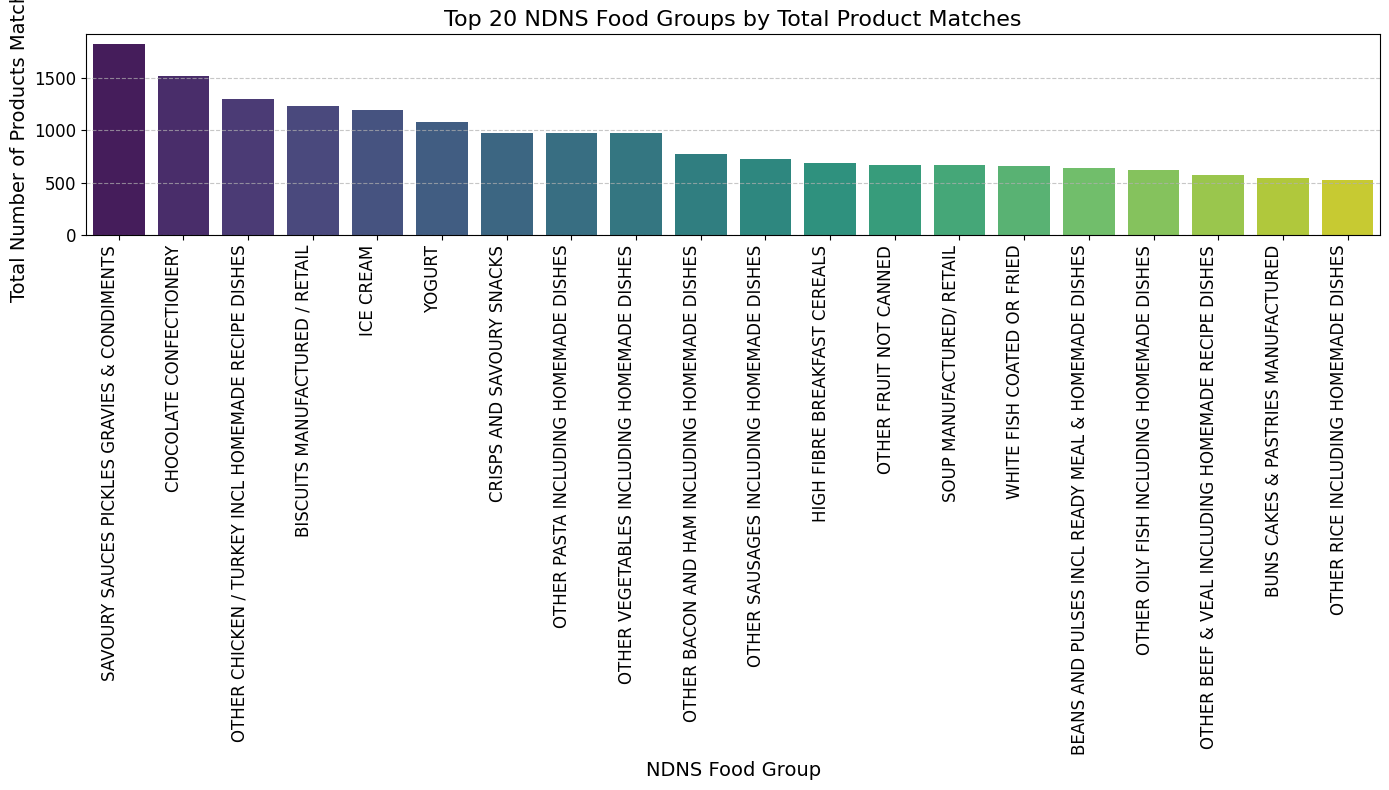

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 8))
sns.barplot(x=food_group_matches.head(20).index, y=food_group_matches.head(20).values, hue=food_group_matches.head(20).index, palette='viridis', legend=False)
plt.title('Top 20 NDNS Food Groups by Total Product Matches', fontsize=16)
plt.xlabel('NDNS Food Group', fontsize=14)
plt.ylabel('Total Number of Products Matched', fontsize=14)
plt.xticks(rotation=90, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
!ls ../../Publication\ data\ and\ notebooks

 COunt_distributions.png	     df_inclusion_total.csv
 df_impacts_per_100g_1902.parquet    diet_data_SHeS_2021.parquet
 df_inclusion_counts_FM.parquet     'Identify missing matches.ipynb'
 df_inclusion_counts_gpt.parquet     NDB_foodDB_matched_data_final.csv
 df_inclusion_counts_total.parquet   NDB_matching_data_FINAL.csv


In [ ]:
df_gpt_counts = pd.read_parquet("../../Publication data and notebooks/df_inclusion_counts_gpt.parquet")
df_fm_counts = pd.read_parquet("../../Publication data and notebooks/df_inclusion_counts_FM.parquet")

In [ ]:
# Reset the index to convert the index (ndb_cat) into a column
df_gpt_counts = df_gpt_counts.reset_index()
df_fm_counts = df_fm_counts.reset_index()

# Rename the index column to 'ndb_cat' to match ndb_df
df_gpt_counts = df_gpt_counts.rename(columns={'index': 'ndb_cat'})
df_fm_counts = df_fm_counts.rename(columns={'index': 'ndb_cat'})

# Merge df_gpt_counts with ndb_df to add the 'NDNS Food group' column
df_gpt_counts = pd.merge(df_gpt_counts, ndb_df[['ndb_cat', 'NDNS Food group']], on='ndb_cat', how='left')
df_fm_counts = pd.merge(df_fm_counts, ndb_df[['ndb_cat', 'NDNS Food group']], on='ndb_cat', how='left')


### Distribution of GPT Match Counts by NDNS Food Group

In [ ]:
gpt_food_group_counts = df_gpt_counts.groupby('NDNS Food group')['count'].sum().sort_values(ascending=False)
display(gpt_food_group_counts.head(20))

print(f"\nTotal unique NDNS Food Groups in GPT data: {len(gpt_food_group_counts)}")
print(f"Mean total GPT matches per food group: {gpt_food_group_counts.mean():.2f}")
print(f"Median total GPT matches per food group: {gpt_food_group_counts.median():.2f}")

,count
NDNS Food group,
CHOCOLATE CONFECTIONERY,1861
SAVOURY SAUCES PICKLES GRAVIES & CONDIMENTS,1825
YOGURT,1628
BISCUITS MANUFACTURED / RETAIL,1478
ICE CREAM,1405
CRISPS AND SAVOURY SNACKS,1387
OTHER CHICKEN / TURKEY INCL HOMEMADE RECIPE DISHES,1320
OTHER PASTA INCLUDING HOMEMADE DISHES,1025
OTHER BACON AND HAM INCLUDING HOMEMADE DISHES,875



Total unique NDNS Food Groups in GPT data: 136
Mean total GPT matches per food group: 305.43
Median total GPT matches per food group: 178.50


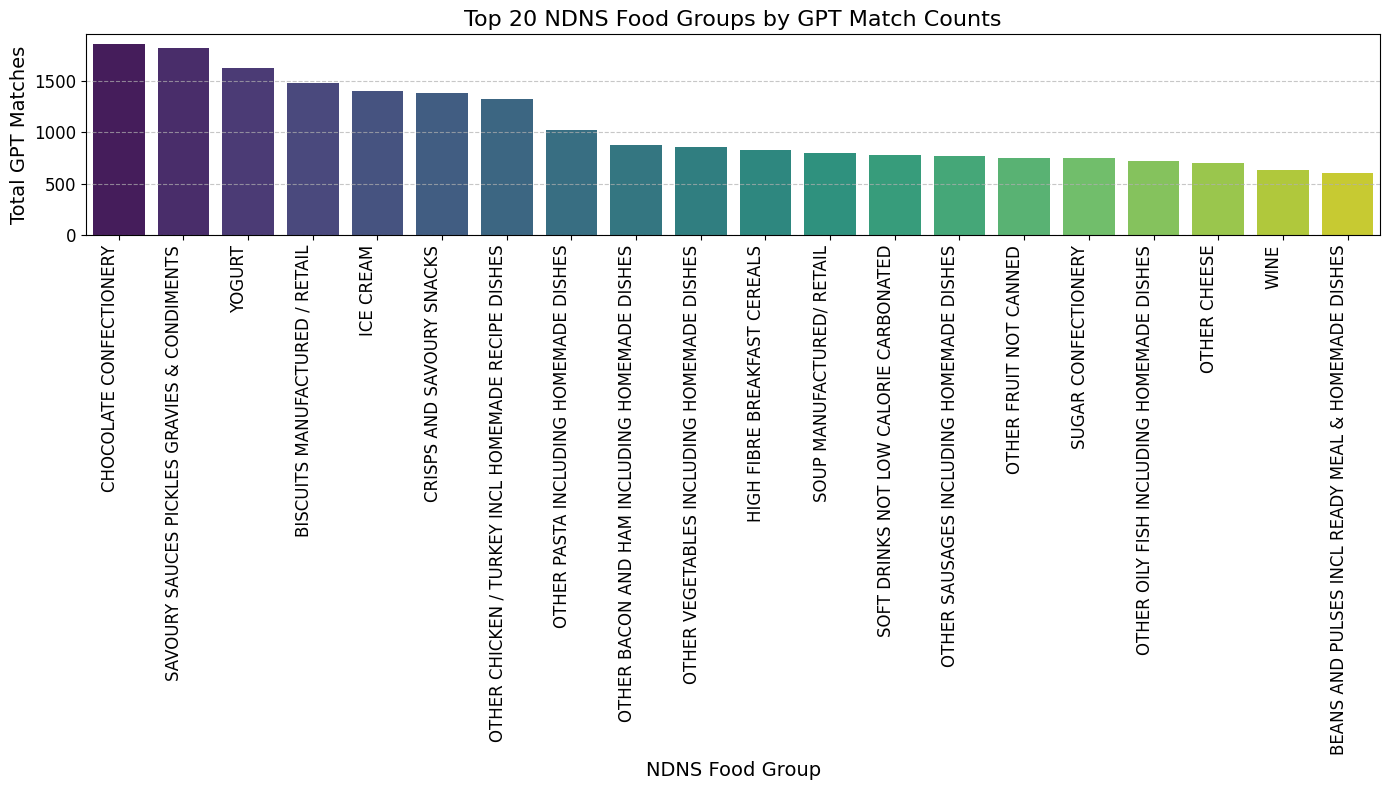

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 8))
sns.barplot(x=gpt_food_group_counts.head(20).index, y=gpt_food_group_counts.head(20).values, hue=gpt_food_group_counts.head(20).index, palette='viridis', legend=False)
plt.title('Top 20 NDNS Food Groups by GPT Match Counts', fontsize=16)
plt.xlabel('NDNS Food Group', fontsize=14)
plt.ylabel('Total GPT Matches', fontsize=14)
plt.xticks(rotation=90, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
fm_food_group_counts = df_fm_counts.groupby('NDNS Food group')['count'].sum().sort_values(ascending=False)
display(fm_food_group_counts.head(20))

print(f"\nTotal unique NDNS Food Groups in FM data: {len(fm_food_group_counts)}")
print(f"Mean total FM matches per food group: {fm_food_group_counts.mean():.2f}")
print(f"Median total FM matches per food group: {fm_food_group_counts.median():.2f}")

,count
NDNS Food group,
SAVOURY SAUCES PICKLES GRAVIES & CONDIMENTS,691
BISCUITS MANUFACTURED / RETAIL,475
CHOCOLATE CONFECTIONERY,320
OTHER CHICKEN / TURKEY INCL HOMEMADE RECIPE DISHES,319
OTHER VEGETABLES INCLUDING HOMEMADE DISHES,276
OTHER FRUIT NOT CANNED,227
NUTS AND SEEDS,215
BUNS CAKES & PASTRIES MANUFACTURED,206
SOUP MANUFACTURED/ RETAIL,193



Total unique NDNS Food Groups in FM data: 143
Mean total FM matches per food group: 53.47
Median total FM matches per food group: 20.00


### Comparison of FM and GPT-4 Match Counts by NDNS Food Group

In [ ]:
# Combine the two series into a DataFrame for comparison
comparison_df = pd.DataFrame({
    'FM_Matches': fm_food_group_counts,
    'GPT_Matches': gpt_food_group_counts
}).fillna(0) # Fill NaN with 0 for food groups present in one but not the other

# Calculate the difference (GPT - FM) to see which is higher
comparison_df['Difference'] = comparison_df['GPT_Matches'] - comparison_df['FM_Matches']

# Calculate the ratio (GPT / FM) to see proportional differences, handling division by zero
comparison_df['Ratio_GPT_to_FM'] = comparison_df.apply(lambda row: row['GPT_Matches'] / row['FM_Matches'] if row['FM_Matches'] != 0 else np.inf, axis=1)

# Sort by difference to see where GPT-4 has more matches
print("\n--- Top 10 Food Groups where GPT-4 has significantly MORE matches than FM ---")
display(comparison_df.sort_values(by='Difference', ascending=False).head(10))

# Sort by difference to see where FM has significantly MORE matches than GPT-4
print("\n--- Top 10 Food Groups where FM has significantly MORE matches than GPT-4 ---")
display(comparison_df.sort_values(by='Difference', ascending=True).head(10))


--- Top 10 Food Groups where GPT-4 has significantly MORE matches than FM ---


,FM_Matches,GPT_Matches,Difference,Ratio_GPT_to_FM
NDNS Food group,,,,
CHOCOLATE CONFECTIONERY,320,1861.0,1541.0,5.815625
YOGURT,120,1628.0,1508.0,13.566667
CRISPS AND SAVOURY SNACKS,77,1387.0,1310.0,18.012987
ICE CREAM,100,1405.0,1305.0,14.050000
SAVOURY SAUCES PICKLES GRAVIES & CONDIMENTS,691,1825.0,1134.0,2.641100
BISCUITS MANUFACTURED / RETAIL,475,1478.0,1003.0,3.111579
OTHER CHICKEN / TURKEY INCL HOMEMADE RECIPE DISHES,319,1320.0,1001.0,4.137931
OTHER PASTA INCLUDING HOMEMADE DISHES,52,1025.0,973.0,19.711538
OTHER BACON AND HAM INCLUDING HOMEMADE DISHES,6,875.0,869.0,145.833333



--- Top 10 Food Groups where FM has significantly MORE matches than GPT-4 ---


,FM_Matches,GPT_Matches,Difference,Ratio_GPT_to_FM
NDNS Food group,,,,
SEMI SKIMMED MILK,58,0.0,-58.0,0.000000
CANNED FRUIT IN JUICE,74,39.0,-35.0,0.527027
POLYUNSATURATED LOW FAT SPREAD,13,0.0,-13.0,0.000000
HOMEMADE MEAT PIES AND PASTRIES,12,0.0,-12.0,0.000000
SKIMMED MILK,11,0.0,-11.0,0.000000
READY MEALS BASED ON SAUSAGES,11,0.0,-11.0,0.000000
BANANAS,4,0.0,-4.0,0.000000
OTHER MEAT INCLUDING HOMEMADE RECIPE DISHES,3,0.0,-3.0,0.000000
DAIRY DESSERTS HOMEMADE,2,0.0,-2.0,0.000000


In [ ]:
len(comparison_df)

143

In [ ]:
display(comparison_df.sort_values(by='Difference', ascending=True).head(20))

,FM_Matches,GPT_Matches,Difference,Ratio_GPT_to_FM
NDNS Food group,,,,
SEMI SKIMMED MILK,58,0.0,-58.0,0.000000
CANNED FRUIT IN JUICE,74,39.0,-35.0,0.527027
POLYUNSATURATED LOW FAT SPREAD,13,0.0,-13.0,0.000000
HOMEMADE MEAT PIES AND PASTRIES,12,0.0,-12.0,0.000000
SKIMMED MILK,11,0.0,-11.0,0.000000
READY MEALS BASED ON SAUSAGES,11,0.0,-11.0,0.000000
BANANAS,4,0.0,-4.0,0.000000
OTHER MEAT INCLUDING HOMEMADE RECIPE DISHES,3,0.0,-3.0,0.000000
DAIRY DESSERTS HOMEMADE,2,0.0,-2.0,0.000000


In [ ]:
supplementary_data = comparison_df.sort_values(by='Difference', ascending=False)

In [ ]:
supplementary_data.drop(columns=["Ratio_GPT_to_FM"], inplace=True)

In [ ]:
supplementary_data.to_excel(results_path / "supplementary_data_food_group_comparison.xlsx")

/tmp/ipykernel_3498/131225537.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=comparison_df['Difference'].sort_values(ascending=False).head(20).index,


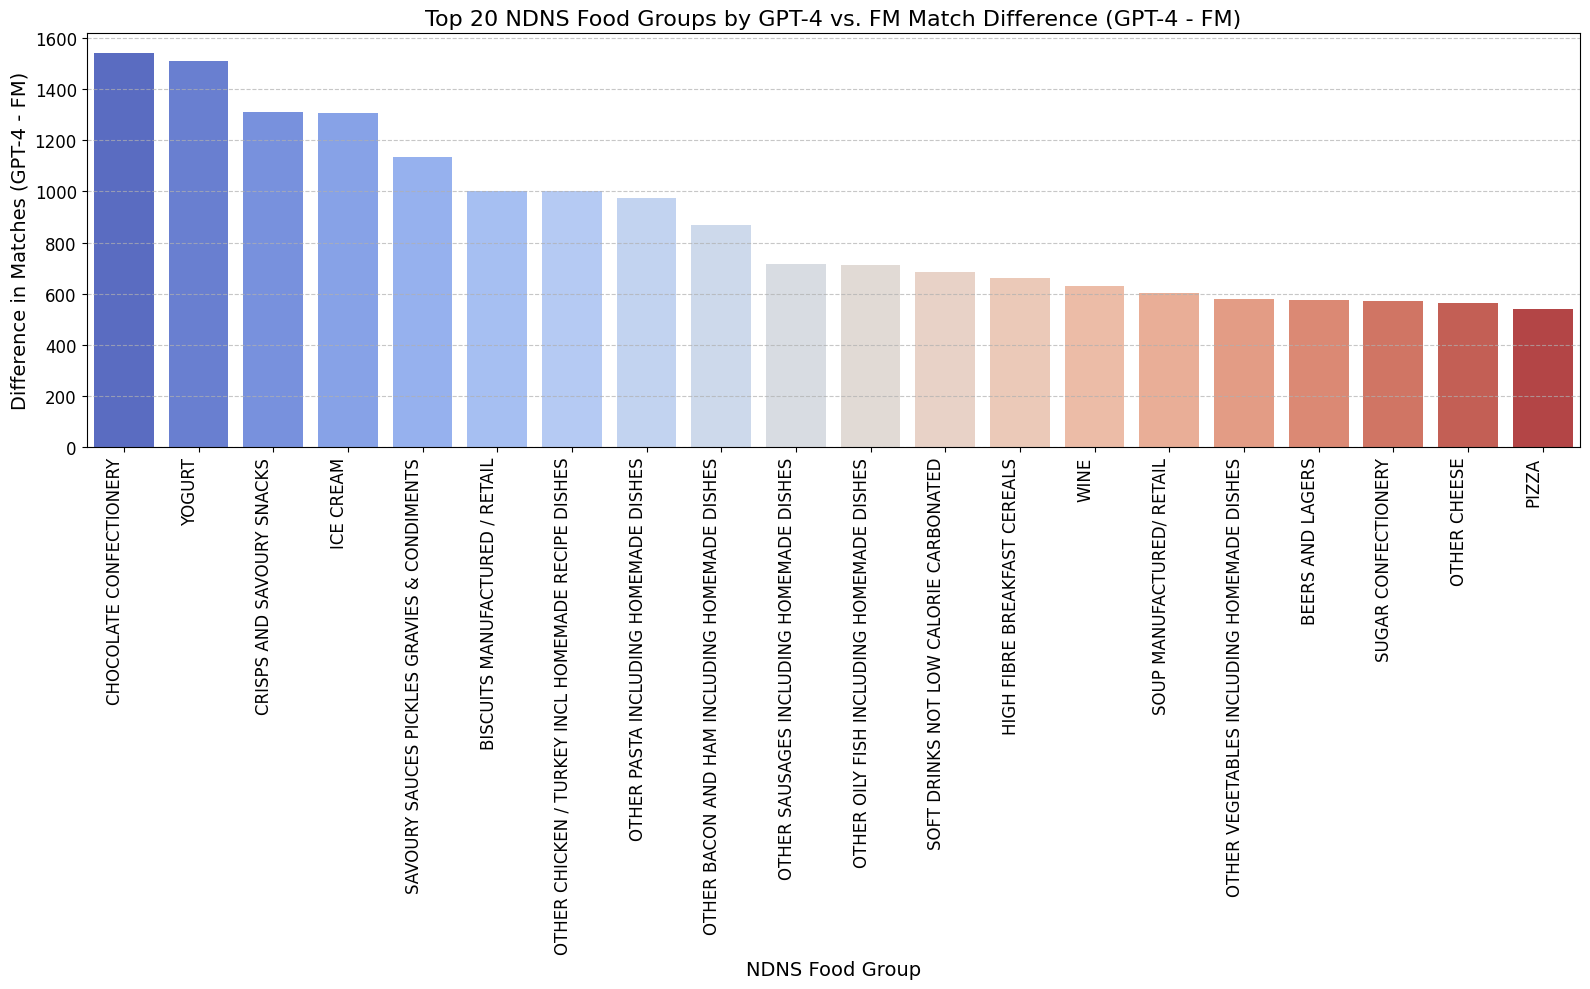

/tmp/ipykernel_3498/131225537.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=comparison_df['Difference'].sort_values(ascending=True).head(20).index,


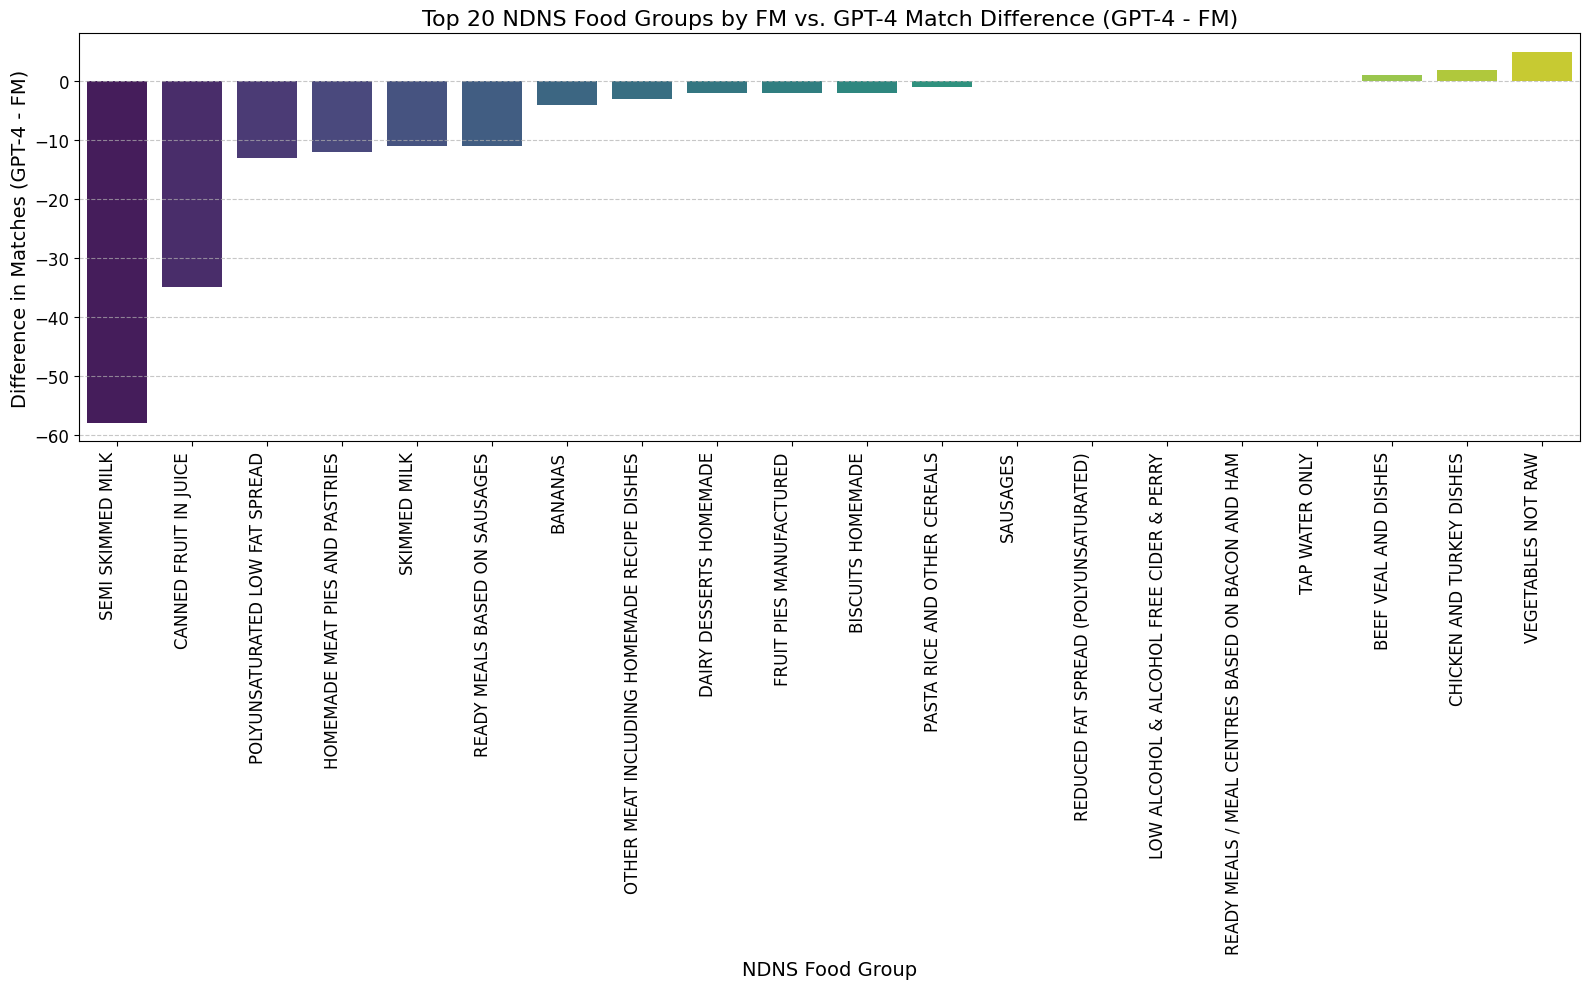

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting the differences for better visualization
plt.figure(figsize=(16, 10))
sns.barplot(x=comparison_df['Difference'].sort_values(ascending=False).head(20).index,
            y=comparison_df['Difference'].sort_values(ascending=False).head(20).values,
            hue=comparison_df['Difference'].sort_values(ascending=False).head(20).index, palette='coolwarm', legend=False)
plt.title('Top 20 NDNS Food Groups by GPT-4 vs. FM Match Difference (GPT-4 - FM)', fontsize=16)
plt.xlabel('NDNS Food Group', fontsize=14)
plt.ylabel('Difference in Matches (GPT-4 - FM)', fontsize=14)
plt.xticks(rotation=90, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

plt.figure(figsize=(16, 10))
sns.barplot(x=comparison_df['Difference'].sort_values(ascending=True).head(20).index,
            y=comparison_df['Difference'].sort_values(ascending=True).head(20).values,
            hue=comparison_df['Difference'].sort_values(ascending=True).head(20).index, palette='viridis', legend=False)
plt.title('Top 20 NDNS Food Groups by FM vs. GPT-4 Match Difference (GPT-4 - FM)', fontsize=16)
plt.xlabel('NDNS Food Group', fontsize=14)
plt.ylabel('Difference in Matches (GPT-4 - FM)', fontsize=14)
plt.xticks(rotation=90, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
df_impacts[df_impacts['NDNS Food group']=='SAUSAGES']

,ndb_cat,tot_num_products,num_prods_fooddb_2022,num_prods_fooddb_2021,num_prods_fooddb_2019,num_prods_open_food_facts,num_prods_recipeDB,sd_mean_GHG,sd_mean_Land,sd_mean_WatScar,...,mean_WaterUse,mean_Biodiversity,median_GHG,median_Land,median_WatScar,median_Eut,median_Acidification,median_WaterUse,median_Biodiversity,NDNS Food group
1318,Hot dog/frankfurter with sauce in a bun,1,0,0,0,0,1,0.415105,0.657698,4795.525113,...,147.258313,26.476066,0.78142,1.099558,5438.747007,2.904587,6.509584,165.641647,15.27229,SAUSAGES


In [ ]:
df_impacts[df_impacts['ndb_cat']=='Sausage casserole/stew']

,ndb_cat,tot_num_products,num_prods_fooddb_2022,num_prods_fooddb_2021,num_prods_fooddb_2019,num_prods_open_food_facts,num_prods_recipeDB,sd_mean_GHG,sd_mean_Land,sd_mean_WatScar,...,mean_WaterUse,mean_Biodiversity,median_GHG,median_Land,median_WatScar,median_Eut,median_Acidification,median_WaterUse,median_Biodiversity,NDNS Food group
2320,Sausage casserole/stew,3,1,1,1,0,0,0.074957,0.051554,193.735226,...,21.621303,3.174079,0.126497,0.217212,733.386361,0.553636,1.674387,17.888336,1.588648,OTHER SAUSAGES INCLUDING HOMEMADE DISHES


In [ ]:
for item in df_impacts['ndb_cat'].unique():
  if 'sausage' in item.lower():
    print(item)

Baked beans and sausages
Beef Sausage, grilled
Beef sausage, uncooked
Bierwurst/garlic sausage
Chicken/turkey sausage, fried
Chicken/turkey sausage, grilled
Liver Sausage
Pasta with meat and tomato-based sauce, canned (e.g. pasta with sausages)
Pork Sausage, reduced fat
Pork sausage, grilled
Pork sausage, uncooked
Quorn sausages
Sausage and egg in a bun/muffin (e.g. Sausage and egg McMuffin)
Sausage burger, in a bun
Sausage casserole mix, dry/packet
Sausage casserole/stew
Sausage in batter, fried
Sausage meat stuffing
Sausage roll
Sausage sandwich with ketchup with white/malted bread or roll
Sausage sandwich with ketchup with wholemeal/oatmeal bread or roll
Sausage with vegetable mash, ready meal, reduced fat (e.g. Weight Watchers)
Sausage, fried
Smoked Sausage
Square/Lorne sausage
Vegetarian meat-style sausage (e.g. Linda McCartney, Cauldron), NOT Quorn
Vegetarian sausage roll, meat style (e.g. Quorn)
Venison sausage
